In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2  
from moviepy.editor import VideoFileClip
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [ ]:
df=pd.read_csv(r"C:\Users\Shalini Sreeram\CNN_speech_emotion_recognition\audio_text.csv")

In [3]:
df

,File Name,Audio Features,Dialogue_ID,Utterance_ID,Speaker,Emotion,Sentiment,Season,Episode,StartTime,EndTime,Processed_Utterance,Duration,Processed_Utterance_Str
0,dia0_utt0.mp4,"[-297.01422119140625, 153.53903198242188, -49....",0,0,Chandler,neutral,neutral,8,21,"00:16:16,059","00:16:21,731","['also', 'point', 'person', 'transition', 'sys...",5.672,also point person transition system
1,dia0_utt1.mp4,"[-305.7720031738281, 137.69033813476562, -23.7...",0,1,The Interviewer,neutral,neutral,8,21,"00:16:21,940","00:16:23,442","['hand', 'full']",1.502,hand full
2,dia0_utt10.mp4,"[-296.2013854980469, 170.54347229003906, -59.9...",0,10,Chandler,fear,negative,8,21,"00:17:02,856","00:17:04,858",['beg'],2.002,beg
3,dia0_utt11.mp4,"[-296.4863586425781, 136.7867431640625, -41.92...",0,11,The Interviewer,neutral,neutral,8,21,"00:17:05,025","00:17:13,324","['right', 'definite', 'answer', 'monday', 'thi...",8.299,right definite answer monday think say confide...
4,dia0_utt12.mp4,"[-317.79937744140625, 113.78086853027344, -45....",0,12,Chandler,surprise,positive,8,21,"00:17:13,491","00:17:16,536",['really'],3.045,really
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9983,dia9_utt5.mp4,"[-312.27630615234375, 192.239990234375, -57.04...",9,5,Chandler,neutral,neutral,2,5,"0:02:16,261","0:02:16,903",['back'],0.642,back
9984,dia9_utt6.mp4,"[-396.946533203125, 192.0432586669922, -47.444...",9,6,Jade,neutral,neutral,2,5,"0:02:16,903","0:02:19,185","['gon', 'na', 'get', 'together']",2.282,gon na get together
9985,dia9_utt7.mp4,"[-357.1268005371094, 165.3511199951172, -44.15...",9,7,Chandler,neutral,neutral,2,5,"00:02:19,347","00:02:25,561","['um', 'absolutely', 'uh', 'tomorrow', 'aftern...",6.214,um absolutely uh tomorrow afternoon know uh ce...
9986,dia9_utt8.mp4,"[-407.03076171875, 154.23944091796875, -39.508...",9,8,Jade,neutral,neutral,2,5,"00:02:25,770","00:02:28,647","['great', 'see']",2.877,great see


In [4]:
import ast

# Convert the 'Audio Features' column to a list of lists
df['Audio Features'] = df['Audio Features'].apply(ast.literal_eval)

# Calculate the length of each list in the 'Audio Features' column
df['Features Length'] = df['Audio Features'].apply(len)


In [5]:
data=df

In [6]:
df=df.drop(["Sentiment","StartTime","EndTime"], axis=1)

In [7]:
df

,File Name,Audio Features,Dialogue_ID,Utterance_ID,Speaker,Emotion,Season,Episode,Processed_Utterance,Duration,Processed_Utterance_Str,Features Length
0,dia0_utt0.mp4,"[-297.01422119140625, 153.53903198242188, -49....",0,0,Chandler,neutral,8,21,"['also', 'point', 'person', 'transition', 'sys...",5.672,also point person transition system,13
1,dia0_utt1.mp4,"[-305.7720031738281, 137.69033813476562, -23.7...",0,1,The Interviewer,neutral,8,21,"['hand', 'full']",1.502,hand full,13
2,dia0_utt10.mp4,"[-296.2013854980469, 170.54347229003906, -59.9...",0,10,Chandler,fear,8,21,['beg'],2.002,beg,13
3,dia0_utt11.mp4,"[-296.4863586425781, 136.7867431640625, -41.92...",0,11,The Interviewer,neutral,8,21,"['right', 'definite', 'answer', 'monday', 'thi...",8.299,right definite answer monday think say confide...,13
4,dia0_utt12.mp4,"[-317.79937744140625, 113.78086853027344, -45....",0,12,Chandler,surprise,8,21,['really'],3.045,really,13
...,...,...,...,...,...,...,...,...,...,...,...,...
9983,dia9_utt5.mp4,"[-312.27630615234375, 192.239990234375, -57.04...",9,5,Chandler,neutral,2,5,['back'],0.642,back,13
9984,dia9_utt6.mp4,"[-396.946533203125, 192.0432586669922, -47.444...",9,6,Jade,neutral,2,5,"['gon', 'na', 'get', 'together']",2.282,gon na get together,13
9985,dia9_utt7.mp4,"[-357.1268005371094, 165.3511199951172, -44.15...",9,7,Chandler,neutral,2,5,"['um', 'absolutely', 'uh', 'tomorrow', 'aftern...",6.214,um absolutely uh tomorrow afternoon know uh ce...,13
9986,dia9_utt8.mp4,"[-407.03076171875, 154.23944091796875, -39.508...",9,8,Jade,neutral,2,5,"['great', 'see']",2.877,great see,13


In [8]:
# Convert 'Audio Features' and 'Emotion' columns to NumPy arrays
audio_features = df['Audio Features'].apply(lambda x: np.array(x, dtype=float)).to_numpy()
emotions = df['Emotion'].to_numpy()
file_paths = df['File Name'].to_numpy()


In [9]:
audio_features

array([array([-2.97014221e+02,  1.53539032e+02, -4.90380211e+01,  5.46977043e+01,
              -5.27428484e+00,  6.43434191e+00, -3.85622478e+00, -1.16022074e+00,
               1.19830534e-01, -8.91124153e+00,  1.22017086e+00,  3.14986753e+00,
              -3.25099730e+00])                                                  ,
       array([-305.77200317,  137.69033813,  -23.75961876,   50.2026825 ,
                -2.27249265,    5.5844698 ,   -0.9529689 ,   -1.49110889,
               -14.78405285,   -3.26989985,    0.4343493 ,   -5.73031712,
                 0.49802315])                                            ,
       array([-296.2013855 ,  170.54347229,  -59.91713715,   15.52770996,
               -11.92023182,   -0.72530061,   -5.87638903,  -11.01383018,
                -5.43226624,  -11.78423595,   -7.7017417 ,    3.51267433,
                -3.61513329])                                            ,
       ...,
       array([-357.12680054,  165.35112   ,  -44.15581894,   11.4

In [10]:
# Convert emotion labels to numerical values
emotion_to_num = {label: idx for idx, label in enumerate(set(emotions))}
numeric_emotions = np.array([emotion_to_num[emotion] for emotion in emotions])


In [11]:
# Determine the maximum length of feature arrays
max_length = max(len(features) for features in audio_features)

# Pad all feature arrays to the maximum length
padded_features = np.array([
    np.pad(features, (0, max_length - len(features)), 'constant') for features in audio_features
])


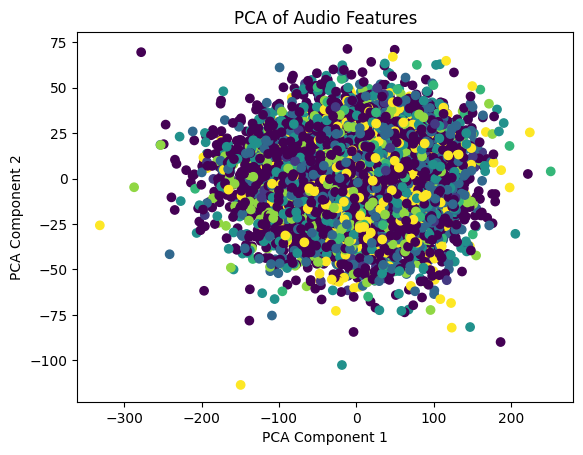

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_features = pca.fit_transform(padded_features)

plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=numeric_emotions)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Audio Features')
plt.show()


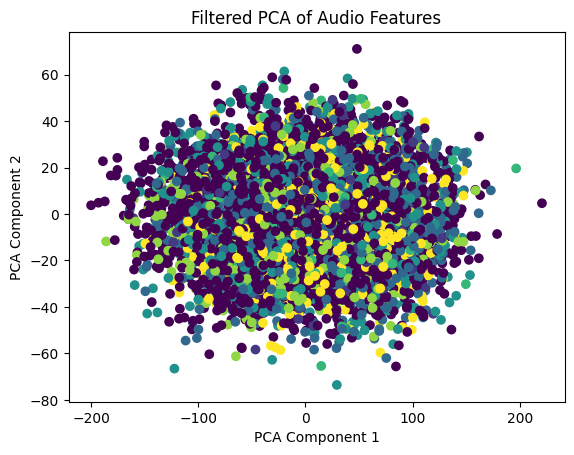

Type of audio_features: <class 'numpy.ndarray'>
Shape of audio_features: (8989, 13)
Shape after stacking: (8989, 13)
Cleaned audio features shape: (8627, 13)
Cleaned emotions shape: (8627,)
Cleaned file paths length: 8627


In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy import stats

# Assuming filtered_features, filtered_labels, and file_paths are defined
clf = IsolationForest(contamination=0.1)
outliers = clf.fit_predict(padded_features)

# Filter out the outliers
inliers_mask = outliers != -1
filtered_features = padded_features[inliers_mask]
filtered_labels = numeric_emotions[inliers_mask]
filtered_file_paths = file_paths[inliers_mask]

# Visualize filtered data
pca = PCA(n_components=2)
filtered_reduced_features = pca.fit_transform(filtered_features)
plt.scatter(filtered_reduced_features[:, 0], filtered_reduced_features[:, 1], c=filtered_labels)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Filtered PCA of Audio Features')
plt.show()

# Check the type and shape of the audio_features
print(f"Type of audio_features: {type(filtered_features)}")
print(f"Shape of audio_features: {filtered_features.shape}")

# Ensure all elements in audio_features are numerical arrays
if filtered_features.ndim == 1:
    # If audio_features is 1D, convert to 2D by stacking
    filtered_features = np.vstack(filtered_features)

print(f"Shape after stacking: {filtered_features.shape}")

# Check for and handle any irregular shapes
try:
    # Calculate z-scores
    z_scores = np.abs(stats.zscore(filtered_features, axis=0))
except Exception as e:
    print(f"Error calculating z-scores: {e}")

# Define a threshold (e.g., 3 standard deviations)
threshold = 3

# Find indices where z-score is greater than threshold
outliers = (z_scores > threshold).any(axis=1)

# Filter out outliers
cleaned_audio_features = filtered_features[~outliers]
cleaned_emotions = filtered_labels[~outliers]
cleaned_file_paths = filtered_file_paths[~outliers]

print(f"Cleaned audio features shape: {cleaned_audio_features.shape}")
print(f"Cleaned emotions shape: {cleaned_emotions.shape}")
print(f"Cleaned file paths length: {len(cleaned_file_paths)}")

# Proceed with further processing and model training


In [14]:
cleaned_file_paths

array(['dia0_utt0.mp4', 'dia0_utt1.mp4', 'dia0_utt10.mp4', ...,
       'dia9_utt7.mp4', 'dia9_utt8.mp4', 'dia9_utt9.mp4'], dtype=object)

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

# Assuming df is your original DataFrame containing all the data
# And that you have filtered arrays: cleaned_audio_features, cleaned_emotions, cleaned_file_paths

# Create a boolean mask for the rows that correspond to cleaned data
mask = df['File Name'].isin(cleaned_file_paths)

# Filter the DataFrame using the mask
cleaned_df = df[mask]

# Extract the cleaned 'Processed_Utterance_Str' column
cleaned_processed_utterance_str = cleaned_df['Processed_Utterance_Str']

# Replace NaN values with empty strings
cleaned_processed_utterance_str = cleaned_processed_utterance_str.fillna('')

# Convert to NumPy array
cleaned_processed_utterance_str = cleaned_processed_utterance_str.values

# Vectorize the 'Processed_Utterance_Str' using Count Vectorizer
vectorizer = CountVectorizer()
vectorized_data = vectorizer.fit_transform(cleaned_processed_utterance_str).toarray()

# Save the vectorized data as a NumPy array
np.save('vectorized_processed_utterance_str.npy', vectorized_data)

# Optionally, save the cleaned Processed_Utterance_Str to check the saved content
np.save('cleaned_processed_utterance_str.npy', cleaned_processed_utterance_str)

# Display the shape of the vectorized data
print(f"Vectorized data shape: {vectorized_data.shape}")


Vectorized data shape: (8627, 4435)


In [16]:
from sklearn.preprocessing import LabelEncoder

# Assuming cleaned_emotions contains the list of emotion labels
label_encoder = LabelEncoder()
encoded_emotions = label_encoder.fit_transform(cleaned_emotions)


In [17]:
from sklearn.model_selection import train_test_split

# Split the combined data into training and test sets
X_train_audio, X_test_audio, X_train_text, X_test_text, y_train, y_test = train_test_split(
    cleaned_audio_features, vectorized_data, encoded_emotions, test_size=0.2, random_state=42
)


In [18]:
pip install optuna


Note: you may need to restart the kernel to use updated packages.


In [19]:
!pip install optuna

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import numpy as np

# Load your dataset here
# X_train_audio, X_test_audio, X_train_text, X_test_text, y_train, y_test should be defined
# Example:
# X_train_audio = np.load('path/to/X_train_audio.npy')
# X_test_audio = np.load('path/to/X_test_audio.npy')
# X_train_text = np.load('path/to/X_train_text.npy')
# X_test_text = np.load('path/to/X_test_text.npy')
# y_train = np.load('path/to/y_train.npy')
# y_test = np.load('path/to/y_test.npy')

class MultiModalModel(nn.Module):
    def __init__(self, embedding_units, hidden_units, optimizer_choice):
        super(MultiModalModel, self).__init__()
        self.text_embedding = nn.Sequential(
            nn.Linear(vectorized_data.shape[1], embedding_units),
            nn.ReLU(),
            nn.Flatten()
        )
        self.audio_fc = nn.Linear(cleaned_audio_features.shape[1], hidden_units)
        self.fc = nn.Linear(embedding_units + hidden_units, len(np.unique(encoded_emotions)))
        
        if optimizer_choice == 'adam':
            self.optimizer_class = optim.Adam
        elif optimizer_choice == 'sgd':
            self.optimizer_class = optim.SGD
        else:
            raise ValueError(f"Unsupported optimizer: {optimizer_choice}")

    def forward(self, audio, text):
        text_features = self.text_embedding(text)
        audio_features = torch.relu(self.audio_fc(audio))
        combined = torch.cat((text_features, audio_features), dim=1)
        output = self.fc(combined)
        return output

def train_model(trial):
    # Hyperparameters to tune
    embedding_units = trial.suggest_int('embedding_units', 32, 128, step=32)
    hidden_units = trial.suggest_int('hidden_units', 64, 256, step=64)
    optimizer_choice = trial.suggest_categorical('optimizer', ['adam', 'sgd'])
    
    model = MultiModalModel(embedding_units, hidden_units, optimizer_choice)
    criterion = nn.CrossEntropyLoss()
    optimizer = model.optimizer_class(model.parameters(), lr=trial.suggest_loguniform('lr', 1e-5, 1e-1))

    # Training loop
    for epoch in range(10):  # Change as needed
        model.train()
        for batch in range(0, len(X_train_audio), 32):  # Batch size is 32
            audio_batch = torch.tensor(X_train_audio[batch:batch+32], dtype=torch.float32)
            text_batch = torch.tensor(X_train_text[batch:batch+32], dtype=torch.float32)
            labels_batch = torch.tensor(y_train[batch:batch+32], dtype=torch.long)
            
            optimizer.zero_grad()
            outputs = model(audio_batch, text_batch)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()
        
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in range(0, len(X_test_audio), 32):
            audio_batch = torch.tensor(X_test_audio[batch:batch+32], dtype=torch.float32)
            text_batch = torch.tensor(X_test_text[batch:batch+32], dtype=torch.float32)
            labels_batch = torch.tensor(y_test[batch:batch+32], dtype=torch.long)
            
            outputs = model(audio_batch, text_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    accuracy = correct / total
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(train_model, n_trials=50)  # Number of trials

# Print the best hyperparameters
print(f"Best hyperparameters: {study.best_params}")


[I 2024-08-16 23:43:00,694] A new study created in memory with name: no-name-ee1c9a07-343c-4cb8-8e93-92cce67c4838
[I 2024-08-16 23:43:08,819] Trial 0 finished with value: 0.44727694090382386 and parameters: {'embedding_units': 32, 'hidden_units': 256, 'optimizer': 'adam', 'lr': 0.00023775417060507666}. Best is trial 0 with value: 0.44727694090382386.
[I 2024-08-16 23:43:13,518] Trial 1 finished with value: 0.4165701042873696 and parameters: {'embedding_units': 64, 'hidden_units': 64, 'optimizer': 'sgd', 'lr': 2.117050971740962e-05}. Best is trial 0 with value: 0.44727694090382386.
[I 2024-08-16 23:43:16,478] Trial 2 finished with value: 0.4779837775202781 and parameters: {'embedding_units': 32, 'hidden_units': 128, 'optimizer': 'sgd', 'lr': 0.0034050787082306627}. Best is trial 2 with value: 0.4779837775202781.
[I 2024-08-16 23:43:23,077] Trial 3 finished with value: 0.4936268829663963 and parameters: {'embedding_units': 128, 'hidden_units': 256, 'optimizer': 'sgd', 'lr': 0.04979364058

Best hyperparameters: {'embedding_units': 96, 'hidden_units': 64, 'optimizer': 'sgd', 'lr': 0.09351806517863037}


In [21]:
best_params = study.best_params
final_model = MultiModalModel(
    embedding_units=best_params['embedding_units'],
    hidden_units=best_params['hidden_units'],
    optimizer_choice=best_params['optimizer']
)
final_optimizer = final_model.optimizer_class(final_model.parameters(), lr=best_params['lr'])
final_criterion = nn.CrossEntropyLoss()

# Train the final model
for epoch in range(200):  # Adjust epochs as needed
    final_model.train()
    for batch in range(0, len(X_train_audio), 32):  # Batch size is 32
        audio_batch = torch.tensor(X_train_audio[batch:batch+32], dtype=torch.float32)
        text_batch = torch.tensor(X_train_text[batch:batch+32], dtype=torch.float32)
        labels_batch = torch.tensor(y_train[batch:batch+32], dtype=torch.long)
        
        final_optimizer.zero_grad()
        outputs = final_model(audio_batch, text_batch)
        loss = final_criterion(outputs, labels_batch)
        loss.backward()
        final_optimizer.step()

    # Validation
    final_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in range(0, len(X_test_audio), 32):
            audio_batch = torch.tensor(X_test_audio[batch:batch+32], dtype=torch.float32)
            text_batch = torch.tensor(X_test_text[batch:batch+32], dtype=torch.float32)
            labels_batch = torch.tensor(y_test[batch:batch+32], dtype=torch.long)
            
            outputs = final_model(audio_batch, text_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    accuracy = correct / total
    print(f"Validation accuracy: {accuracy}")


Validation accuracy: 0.47740440324449596
Validation accuracy: 0.47740440324449596
Validation accuracy: 0.4779837775202781
Validation accuracy: 0.4907300115874855
Validation accuracy: 0.4947856315179606
Validation accuracy: 0.507531865585168
Validation accuracy: 0.5121668597914253
Validation accuracy: 0.5139049826187717
Validation accuracy: 0.5179606025492468
Validation accuracy: 0.5202780996523755
Validation accuracy: 0.5191193511008111
Validation accuracy: 0.5162224797219004
Validation accuracy: 0.5162224797219004
Validation accuracy: 0.5179606025492468
Validation accuracy: 0.5179606025492468
Validation accuracy: 0.5179606025492468
Validation accuracy: 0.5162224797219004
Validation accuracy: 0.5144843568945539
Validation accuracy: 0.5098493626882966
Validation accuracy: 0.5040556199304751
Validation accuracy: 0.49942062572421786
Validation accuracy: 0.49942062572421786
Validation accuracy: 0.4976825028968714
Validation accuracy: 0.49536500579374276
Validation accuracy: 0.4889918887601

In [22]:
# Convert all non-string entries to strings
all_words = ' '.join([str(utt) for utt in df['Processed_Utterance_Str']]).split()

# Find the unique words (vocabulary) and their count
vocab = set(all_words)
vocab_size = len(vocab)

print(f"Vocabulary Size: {vocab_size}")


Vocabulary Size: 4612


In [23]:
# Find the unique emotions and count them
unique_emotions = df['Emotion'].unique()
num_classes = len(unique_emotions)


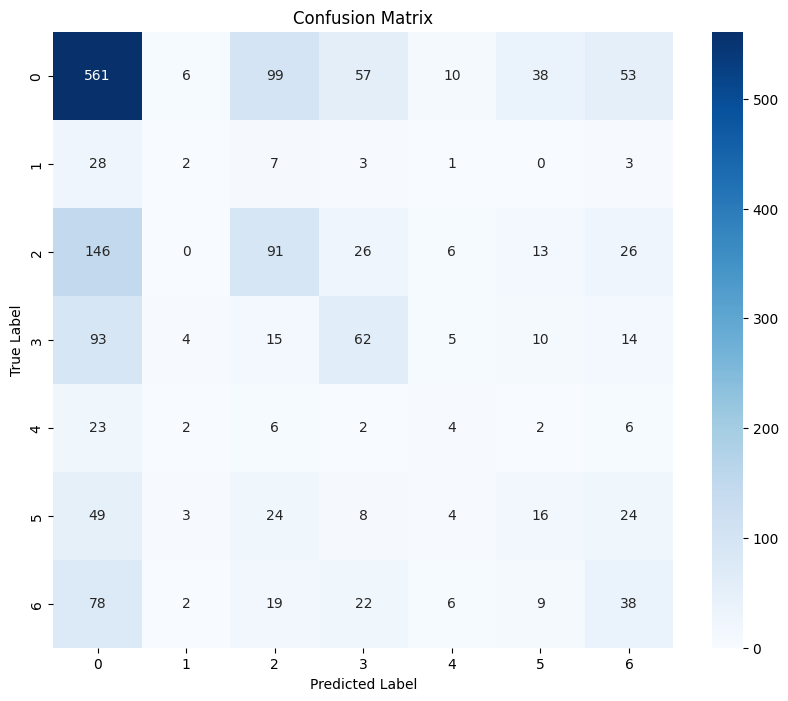

              precision    recall  f1-score   support

           0       0.57      0.68      0.62       824
           1       0.11      0.05      0.06        44
           2       0.35      0.30      0.32       308
           3       0.34      0.31      0.32       203
           4       0.11      0.09      0.10        45
           5       0.18      0.12      0.15       128
           6       0.23      0.22      0.22       174

    accuracy                           0.45      1726
   macro avg       0.27      0.25      0.26      1726
weighted avg       0.42      0.45      0.43      1726



In [25]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

# Generate predictions on the test set
final_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in range(0, len(X_test_audio), 32):
        audio_batch = torch.tensor(X_test_audio[batch:batch+32], dtype=torch.float32)
        text_batch = torch.tensor(X_test_text[batch:batch+32], dtype=torch.float32)
        labels_batch = torch.tensor(y_test[batch:batch+32], dtype=torch.long)
        
        outputs = final_model(audio_batch, text_batch)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

# Decode the encoded labels back to their original string labels
decoded_preds = label_encoder.inverse_transform(all_preds)
decoded_labels = label_encoder.inverse_transform(all_labels)

# Calculate confusion matrix
cm = confusion_matrix(decoded_labels, decoded_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Convert numerical classes to strings if they are not already
target_names = [str(cls) for cls in label_encoder.classes_]

# Print classification report
print(classification_report(decoded_labels, decoded_preds, target_names=target_names))

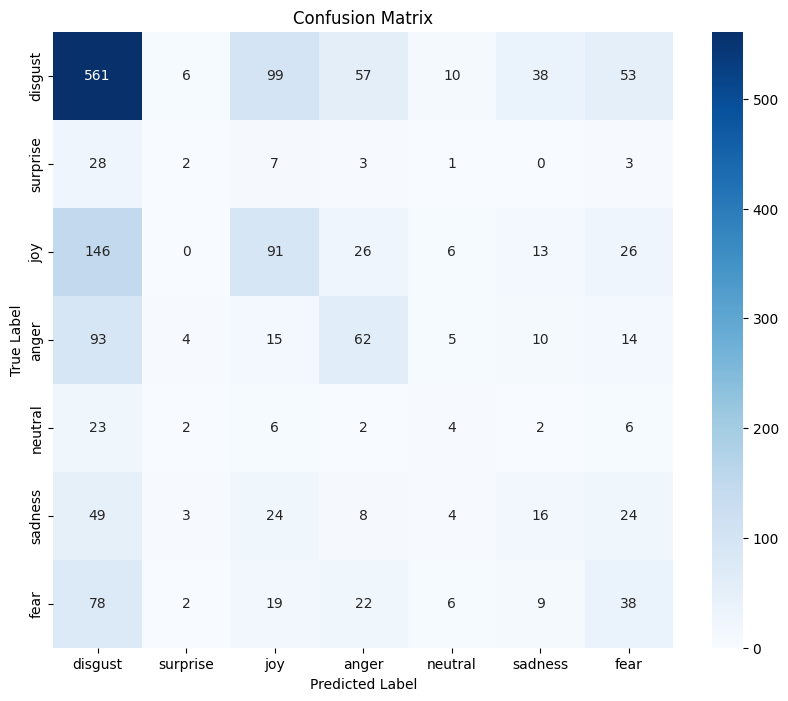

              precision    recall  f1-score   support

     disgust       0.34      0.31      0.32       203
    surprise       0.57      0.68      0.62       824
         joy       0.23      0.22      0.22       174
       anger       0.35      0.30      0.32       308
     neutral       0.11      0.09      0.10        45
     sadness       0.18      0.12      0.15       128
        fear       0.11      0.05      0.06        44

    accuracy                           0.45      1726
   macro avg       0.27      0.25      0.26      1726
weighted avg       0.42      0.45      0.43      1726



In [26]:
# Define the emotion-to-number mapping
emotion_to_num = {'disgust': 0, 'surprise': 1, 'joy': 2, 'anger': 3, 'neutral': 4, 'sadness': 5, 'fear': 6}

# Reverse the dictionary to get number-to-emotion mapping
num_to_emotion = {v: k for k, v in emotion_to_num.items()}

# Assuming your model training and evaluation steps are as before
# ...

# Decode the predictions and labels using the num_to_emotion mapping
decoded_preds = [num_to_emotion[pred] for pred in all_preds]
decoded_labels = [num_to_emotion[label] for label in all_labels]

# Convert dict_values to a list
labels_list = list(num_to_emotion.values())

# Calculate confusion matrix
cm = confusion_matrix(decoded_labels, decoded_preds, labels=labels_list)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_list, yticklabels=labels_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(decoded_labels, decoded_preds, target_names=labels_list))


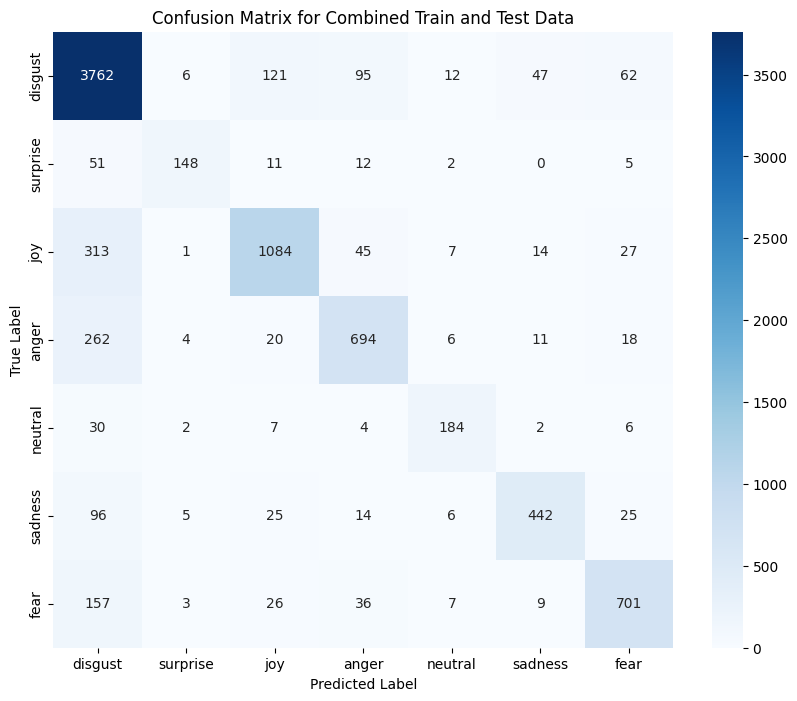

              precision    recall  f1-score   support

     disgust       0.77      0.68      0.72      1015
    surprise       0.81      0.92      0.86      4105
         joy       0.83      0.75      0.79       939
       anger       0.84      0.73      0.78      1491
     neutral       0.82      0.78      0.80       235
     sadness       0.84      0.72      0.78       613
        fear       0.88      0.65      0.74       229

    accuracy                           0.81      8627
   macro avg       0.83      0.75      0.78      8627
weighted avg       0.81      0.81      0.81      8627



In [ ]:
# Reverse the mapping from emotion_to_num
num_to_emotion = {v: k for k, v in emotion_to_num.items()}

# Initialize lists to store combined predictions and labels
all_preds_combined = []
all_labels_combined = []

# Function to get predictions for a given dataset
def get_predictions(model, X_audio, X_text, y):
    preds = []
    labels = []
    with torch.no_grad():
        for batch in range(0, len(X_audio), 32):  # Batch size of 32
            audio_batch = torch.tensor(X_audio[batch:batch+32], dtype=torch.float32)
            text_batch = torch.tensor(X_text[batch:batch+32], dtype=torch.float32)
            labels_batch = torch.tensor(y[batch:batch+32], dtype=torch.long)
            
            outputs = model(audio_batch, text_batch)
            _, predicted = torch.max(outputs.data, 1)
            
            preds.extend(predicted.cpu().numpy())
            labels.extend(labels_batch.cpu().numpy())
    
    return preds, labels

# Get predictions for train data
train_preds, train_labels = get_predictions(final_model, X_train_audio, X_train_text, y_train)
all_preds_combined.extend(train_preds)
all_labels_combined.extend(train_labels)

# Get predictions for test data
test_preds, test_labels = get_predictions(final_model, X_test_audio, X_test_text, y_test)
all_preds_combined.extend(test_preds)
all_labels_combined.extend(test_labels)

# Decode the combined labels back to their original string labels using num_to_emotion
decoded_preds_combined = [num_to_emotion[pred] for pred in all_preds_combined]
decoded_labels_combined = [num_to_emotion[label] for label in all_labels_combined]

# Calculate the confusion matrix
cm_combined = confusion_matrix(decoded_labels_combined, decoded_preds_combined, labels=list(emotion_to_num.keys()))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_to_num.keys(), yticklabels=emotion_to_num.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Combined Train and Test Data')
plt.show()

# Print classification report for combined data
print(classification_report(decoded_labels_combined, decoded_preds_combined, target_names=list(emotion_to_num.keys())))


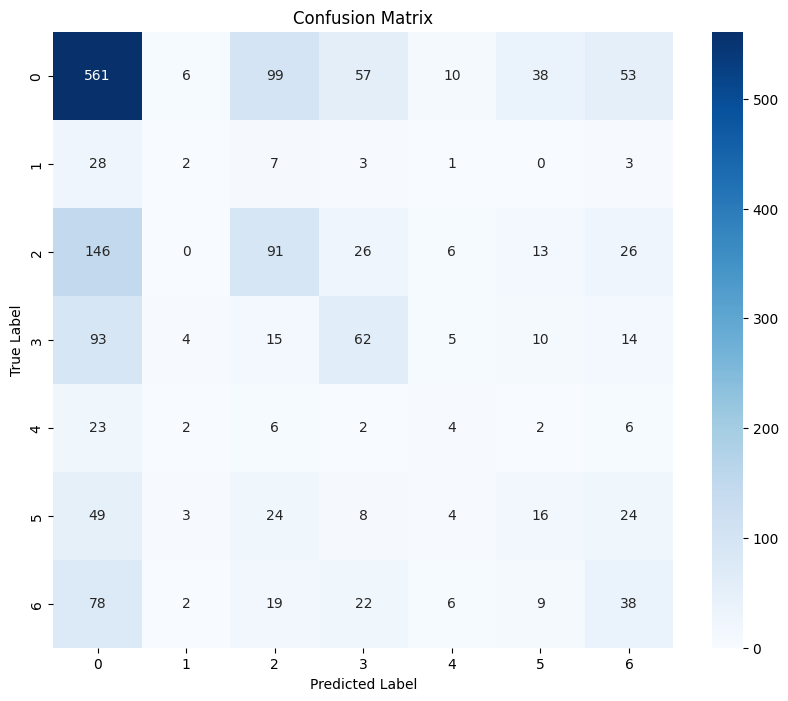

              precision    recall  f1-score   support

           0       0.57      0.68      0.62       824
           1       0.11      0.05      0.06        44
           2       0.35      0.30      0.32       308
           3       0.34      0.31      0.32       203
           4       0.11      0.09      0.10        45
           5       0.18      0.12      0.15       128
           6       0.23      0.22      0.22       174

    accuracy                           0.45      1726
   macro avg       0.27      0.25      0.26      1726
weighted avg       0.42      0.45      0.43      1726



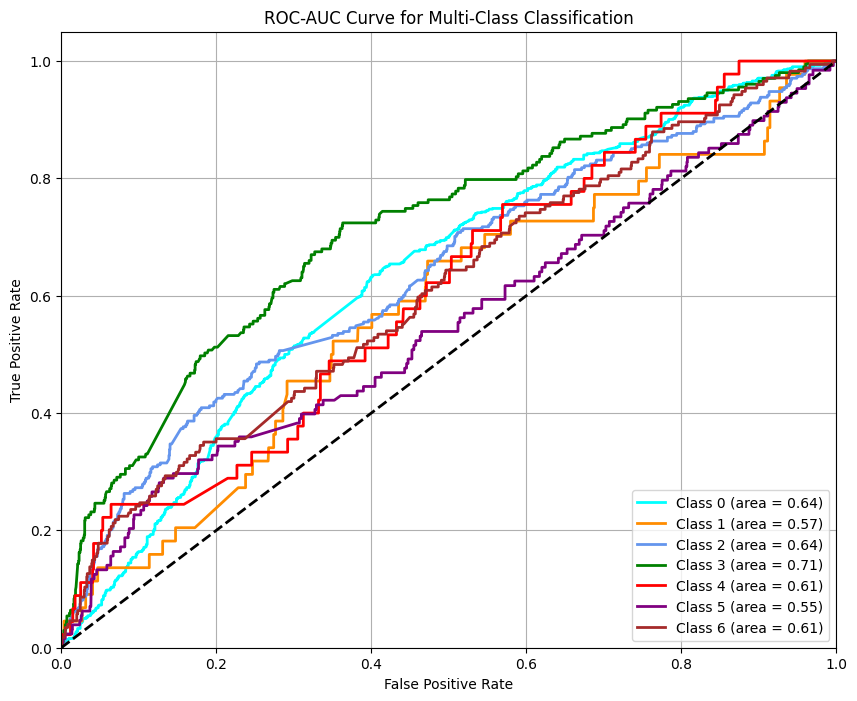

In [28]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from itertools import cycle

# Assuming `final_model`, `X_test_audio`, `X_test_text`, `y_test`, and `label_encoder` are defined

# Generate predictions on the test set
final_model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in range(0, len(X_test_audio), 32):
        audio_batch = torch.tensor(X_test_audio[batch:batch+32], dtype=torch.float32)
        text_batch = torch.tensor(X_test_text[batch:batch+32], dtype=torch.float32)
        labels_batch = torch.tensor(y_test[batch:batch+32], dtype=torch.long)
        
        outputs = final_model(audio_batch, text_batch)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())  # Store probabilities for ROC-AUC calculation

# Decode the encoded labels back to their original string labels
decoded_preds = label_encoder.inverse_transform(all_preds)
decoded_labels = label_encoder.inverse_transform(all_labels)

# Calculate confusion matrix
cm = confusion_matrix(decoded_labels, decoded_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Convert numerical classes to strings if they are not already
target_names = [str(cls) for cls in label_encoder.classes_]

# Print classification report
print(classification_report(decoded_labels, decoded_preds, target_names=target_names))

# Binarize the labels for ROC-AUC curve
y_test_binarized = label_binarize(all_labels, classes=range(len(label_encoder.classes_)))

# Calculate ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(label_encoder.classes_)

all_probs = np.array(all_probs)  # Convert to numpy array for indexing

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve for each class
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {label_encoder.classes_[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for Multi-Class Classification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
